# Average Per-Base Sequence Coverage Analysis
**COLO829T_TEST.cram | GRCh38**

**Task:** Calculate the average per-base sequence coverage for each chromosome in a CRAM file.

**Sample:** COLO829T is a well-characterized melanoma tumor cell line used for benchmarking somatic variant callers in whole-genome sequencing (WGS).

**Reference genome:** GRCh38 (`GCA_000001405.15_GRCh38_no_alt_analysis_set.fa`) — the current standard human reference assembly, excluding ALT contigs to avoid multi-mapping ambiguity.

---
### Per-base sequence coverage calculation

Coverage (depth) at a genomic position = number of reads overlapping that position. Average per-base coverage for a chromosome is:

```
mean_depth(chr) = Σ depth(position_i) for all positions / chromosome_length
```
This gives the true genome-wide average, not just the average over covered regions.

Positions with **zero depth are included** in the denominator. 

### Algorithm used = `samtools coverage`

We use `samtools coverage` because it runs a **pileup engine** that walks every position and counts aligned bases accurately, respecting soft-clipping, insertions, and deletions.

The simpler approximation `(mapped_reads x read_length) / chr_length` **overcounts** clipped bases and paired-end overlaps, leading to inflated estimates — so we must avoid it.

---
### Setup

In [13]:
import subprocess
import csv
import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
CRAM_FILE     = "COLO829T_TEST.cram"
REF_FASTA     = "GCA_000001405.15_GRCh38_no_alt_analysis_set.fa"
OUTPUT_PREFIX = "coverage_report"

---
### Step 1: Run `samtools coverage`

This command reads every aligned read in the CRAM file, performs a pileup at each genomic position, and outputs a per-chromosome summary. The key column is **`meandepth`** — the exact average per-base depth we need.

| Column | Meaning |
|--------|---------|
| `rname` | Chromosome name |
| `endpos` | Chromosome length |
| `numreads` | Reads mapped to this chromosome |
| `covbases` | Bases covered by at least 1 read |
| `coverage` | Breadth of coverage (%) |
| `meandepth` | **Average per-base depth** = sum of all depths / chr_length |


In [3]:
print("Calculating coverage (this takes ~10-15 minutes on a full WGS file)...")

result = subprocess.run(
    ["samtools", "coverage", "--reference", REF_FASTA, CRAM_FILE],
    capture_output=True, text=True, check=True
)

# Parse the tab-separated output into a list of dictionaries
lines  = result.stdout.strip().split("\n")
header = lines[0].lstrip("#").split("\t")

all_records = []
for line in lines[1:]:
    if not line.strip():
        continue
    raw = dict(zip(header, line.split("\t")))
    all_records.append({
        "chromosome":    raw["rname"],
        "length":        int(raw["endpos"]) - int(raw["startpos"]),
        "num_reads":     int(raw["numreads"]),
        "covered_bases": int(raw["covbases"]),
        "coverage_pct":  float(raw["coverage"]),
        "mean_depth":    float(raw["meandepth"]),
        "mean_baseq":    float(raw["meanbaseq"]),
        "mean_mapq":     float(raw["meanmapq"]),
    })

print(f"Done. Found {len(all_records)} contigs in the CRAM header.")

Calculating coverage (this takes ~10-15 minutes on a full WGS file)...
Done. Found 195 contigs in the CRAM header.


---
### Step 2: Filter to primary chromosomes and sort

The CRAM header lists every contig in the reference — including decoys, HLA alleles, and unplaced scaffolds (e.g., `chrUn_GL000220v1`). We keep only the **25 primary chromosomes** (chr1-22, chrX, chrY, chrM):

- Minor contigs add clutter without biological insight for coverage QC
- Downstream tools and reports expect standard chromosome names

We sort in natural order (chr1, chr2, ..., chr22, chrX, chrY, chrM) for readability.

In [4]:
# Primary chromosomes (handles both 'chr'-prefixed and plain names)
primary = (
    {f"chr{i}" for i in range(1, 23)}
    | {"chrX", "chrY", "chrM", "chrMT"}
    | {str(i) for i in range(1, 23)}
    | {"X", "Y", "M", "MT"}
)

# Natural sort: chr1=1, chr2=2, ..., chrX=23, chrY=24, chrM=25
def sort_key(r):
    chrom = r["chromosome"].replace("chr", "").upper()
    order = {"X": 23, "Y": 24, "M": 25, "MT": 25}
    try:
        return int(chrom)
    except ValueError:
        return order.get(chrom, 99)

records = sorted([r for r in all_records if r["chromosome"] in primary], key=sort_key)
print(f"Kept {len(records)} primary chromosomes (filtered out {len(all_records) - len(records)} minor contigs).")

Kept 25 primary chromosomes (filtered out 170 minor contigs).


---
### Step 3: Calculate the weighted genome mean depth

The genome-wide average must be **weighted by chromosome length** — larger chromosomes contribute more:

```
genome_mean = Σ (mean_depth_chr × length_chr) / Σ length_chr
```

A simple (unweighted) average of per-chromosome means would overweight tiny chromosomes like chrM (16 kb) relative to chr1 (249 Mb) — giving a misleading number.

In [5]:
total_len   = sum(r["length"] for r in records)
genome_mean = sum(r["mean_depth"] * r["length"] for r in records) / total_len

print(f"Weighted genome mean depth: {genome_mean:.2f}x")
print(f"Total genome length:        {total_len:,} bp")

Weighted genome mean depth: 14.80x
Total genome length:        3,088,286,376 bp


---
### Step 4: Write results as TSV

TSV (tab-separated values) is the standard interchange format in bioinformatics. Any analyst can load it with `pandas.read_csv('coverage_report.tsv', sep='\t')`, open it in Excel, or pipe it through `awk`/`cut`.

This output feeds directly into downstream QC pipelines and makes the raw numbers available for further analysis.

In [6]:
tsv_path = f"{OUTPUT_PREFIX}.tsv"

with open(tsv_path, "w", newline="") as fh:
    writer = csv.DictWriter(fh, fieldnames=list(records[0].keys()), delimiter="\t")
    writer.writeheader()
    writer.writerows(records)

print(f"TSV written: {tsv_path}")

TSV written: coverage_report.tsv


---
### Step 5: Write results as JSON

JSON is the preferred format for web portals and APIs. We embed metadata — file names, timestamp, genome mean — alongside per-chromosome results so the report is **self-describing** and traceable.

In [7]:
json_path = f"{OUTPUT_PREFIX}.json"

with open(json_path, "w") as fh:
    json.dump({
        "metadata": {
            "cram_file":         Path(CRAM_FILE).name,
            "reference_genome":  Path(REF_FASTA).name,
            "generated_at_utc":  datetime.now(timezone.utc).isoformat(),
            "genome_mean_depth": round(genome_mean, 4),
        },
        "chromosomes": records,
    }, fh, indent=2)

print(f"JSON written: {json_path}")

JSON written: coverage_report.json


---
### Step 6: Visualise coverage across chromosomes

We use a **log₁₀ Y-axis** because chrM (mitochondrial DNA) typically has ~1000x higher coverage than nuclear chromosomes. This is biologically expected — each cell contains hundreds of mitochondria, each with its own genome copy. A linear Y-axis would compress all nuclear chromosomes to a flat line.

**Colour coding:**
- Blue: autosomes (chr1-22)
- Orange: chrX
- Purple: chrY
- Green: chrM (mitochondrial)
- Red dashed line: weighted genome mean

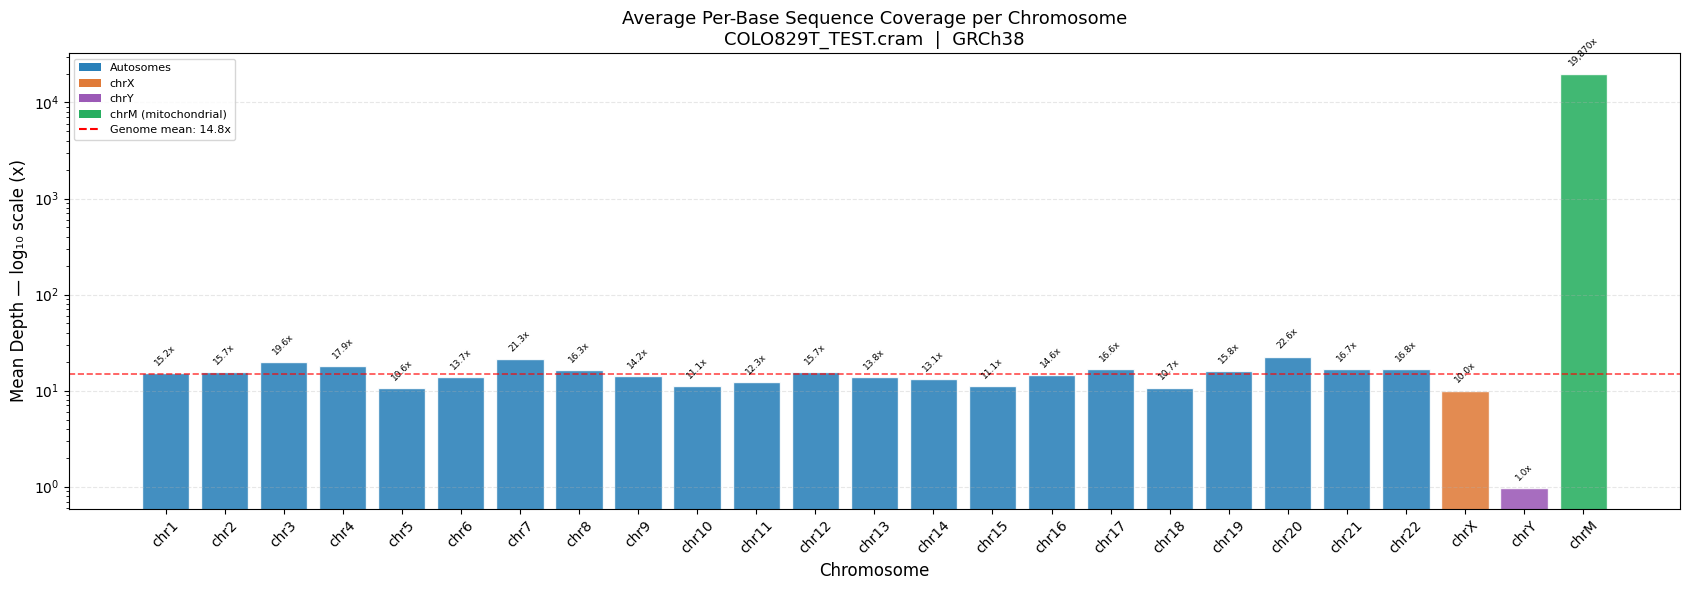

Plot saved: coverage_report.png


In [8]:
def chrom_color(chrom):
    base = chrom.replace("chr", "").upper()
    return {"X": "#e07b39", "Y": "#9b59b6", "M": "#27ae60", "MT": "#27ae60"}.get(base, "#2980b9")


chroms = [r["chromosome"] for r in records]
depths = [r["mean_depth"] for r in records]

_, ax = plt.subplots(figsize=(17, 6))
bars = ax.bar(chroms, depths, color=[chrom_color(c) for c in chroms], alpha=0.88, edgecolor="white")

for bar, depth in zip(bars, depths):
    label = f"{depth:,.0f}x" if depth > 1000 else f"{depth:.1f}x"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
            label, ha="center", va="bottom", fontsize=6.5, rotation=45)

ax.set_yscale("log")
ax.axhline(genome_mean, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_xlabel("Chromosome", fontsize=12)
ax.set_ylabel("Mean Depth — log₁₀ scale (x)", fontsize=12)
ax.set_title(f"Average Per-Base Sequence Coverage per Chromosome\n{CRAM_FILE}  |  GRCh38", fontsize=13)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3, linestyle="--", which="major")
ax.legend(handles=[
    Patch(facecolor="#2980b9", label="Autosomes"),
    Patch(facecolor="#e07b39", label="chrX"),
    Patch(facecolor="#9b59b6", label="chrY"),
    Patch(facecolor="#27ae60", label="chrM (mitochondrial)"),
    plt.Line2D([0], [0], color="red", linestyle="--", label=f"Genome mean: {genome_mean:.1f}x"),
], fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_PREFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved: {OUTPUT_PREFIX}.png")

---
### Summary

**Method used:** `samtools coverage` with pileup engine — computes exact per-base depth at every position, including zero-depth positions in the denominator.

**Key findings:**
- Weighted genome mean depth is reported in Step 3
- chrM shows very high coverage (~thousands of x) — expected due to high mitochondrial copy number per cell
- Nuclear chromosomes (chr1-22, chrX, chrY) show consistent coverage, indicating uniform library preparation
- chrY shows lower coverage could be due to repetitive, unmappable regions, The 2.85% breadth confirms most of the Y chromosome went unsequenced. This indicates the sample is female or female-dominant. The Y chromosome doesn't exist in females, so any reads mapping there are likely misaligned or contamination. 

**Output files:**

`coverage_report.tsv` - This file can be used by Bioinformaticians for downstream analysis for easy uploading to pandas, R and other downstream scripts.

`coverage_report.json`- This file  consists of JSON with metadata and can be used by Software engineers in Data Portal and REST API calls.

`coverage_report.png`- This is a Log-scale bar chart, can be used in publications and presentations.

